# Two impurities (fitting)

In [12]:
import kwant
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from amsc import (
    impurity_system,
    bulk_amsc_system,
    generate_intial_Delta,
    setup_gaussian_impurities,
)
from plot_tools import add_tl_label, multiplot
from tqdm.notebook import tqdm
from pauli import *
from qm_tools import sparse_diag, sort_eigensystem

In [13]:
# eigsh = sla.eigsh
eigsh = sparse_diag  # MUMPS

In [14]:
plt.style.use("../plot_style.mplstyle")

In [15]:
periodic_bc = True

Nx = 111
Ny = 111

x_ax = np.linspace(-(Nx // 2), (Nx // 2), Nx)
y_ax = np.linspace(-(Ny // 2), (Ny // 2), Ny)
x, y = np.meshgrid(x_ax, y_ax)

t = 5.0
t_so = 0.0 * t
t_am = 0.2 * t

mu = 2.75
hz0 = 1e-6
hx0 = 0
hy0 = 0

## Initial value for Delta (will be used to determine g)
Delta_init = 1

In [16]:
vortex_positions = []
windings = []
l_core = 0  # l_core is the decay length of the order parameter (in a vortex that is the coherence length)

Delta, theta = generate_intial_Delta(
    x=x,
    y=y,
    Delta_init=Delta_init,
    vortex_positions=vortex_positions,
    windings=windings,
    l_core=l_core,
)

In [17]:
# Impurituy positions
impurity_positions = [(0, 0), (0, 0)]  # , (-10, 0)]
impurity_sizes = [2.2, 2.2]  # Sizes
impurity_eccentricities = [0.0, 0.0]  # Eccentricity
impurity_orientation = [0.0, 0.0]  # Orientation


V_imp = [-19, -19]  # Impurity potential (negative = attractive)
hx_imp = [0.0, 0.0]  # Impurity field
hy_imp = [0.0, 0.0]  # Impurity field
hz_imp = [0.0, 0.0]  # Impurity field

In [18]:
N = 20  # Number of eigenvalues to calculate

In [19]:
ds = np.arange(51, 14, -1)
P = len(ds)

gamma = np.pi/8

wss_d = np.zeros((P, N))
vss_d = np.zeros((P, 4 * Nx**2, N), dtype=complex)

for i, d in tqdm(enumerate(ds), total=len(ds)):

    V, hx, hy, hz = setup_gaussian_impurities(
        x=x,
        y=y,
        mu=mu,
        hx0=hx0,
        hy0=hy0,
        hz0=hz0,
        impurity_sizes=impurity_sizes,        
        impurity_positions=[
            (0, 0),
            (np.around(d * np.sin(gamma)), np.around(d * np.cos(gamma))),
        ],
        impurity_eccentricities=impurity_eccentricities,
        impurity_orientations=impurity_orientation,
        V_imp=V_imp,
        hx_imp=hx_imp,
        hy_imp=hy_imp,
        hz_imp=hz_imp,
    )

    syst, lat = bulk_amsc_system(
        Nx=Nx,
        Ny=Ny,
        t=t,
        t_so=t_so,
        t_am=t_am,
        V=V,
        Delta=Delta,
        theta=theta,
        hx=hx,
        hy=hy,
        hz=hz,
        periodic_bc=periodic_bc,
    )

    fsyst = syst.finalized()

    ws, vs = eigsh(fsyst.hamiltonian_submatrix(sparse=True), k=N, sigma=0)

    wss_d[i] = ws
    vss_d[i] = vs

  0%|          | 0/37 [00:00<?, ?it/s]

In [20]:
wss, vss = sort_eigensystem(wss_d, vss_d)

In [21]:
idxs = (-1 / (wss_d[0])).argsort()

In [22]:
t0sz_op = kwant.operator.Density(fsyst, onsite=t0sz, sum=False)
t0s0_op = kwant.operator.Density(fsyst, onsite=t0s0, sum=False)

In [23]:
szs = np.zeros((P, 4))

for n in range(4):
    for p in range(P):
        szs[p, n] = t0sz_op(vss[p, :, idxs[n]]).sum()

szs = szs.clip(-1, 1)

colors = np.zeros((P, N, 4))
colors[:] = (0.5, 0.5, 0.5, 0.5)

for p in range(P):
    for n in range(4):
        colors[p, idxs[n], :] = ((1 + szs[p, n]) / 2, 0, (1 - szs[p, n]) / 2, 1)

markers = np.zeros((P, N), dtype=str)
markers[:] = "."

linestyles = np.zeros(N, dtype="<U2")
linestyles[:] = "--"

for n in range(4):
    linestyles[idxs[n]] = "--" if n % 2 == 0 else "-"

In [24]:
idxp = np.argwhere(ds == 20)[0][0]

In [25]:
lmb_om = 2*np.pi*np.sqrt(t/mu)*np.sqrt(1 - t_am / t) 
lmb_om 

np.float64(7.577806600795863)

In [26]:
lmb_op = 2*np.pi*np.sqrt(t/mu)*np.sqrt(1  + t_am / t) 
lmb_op 

np.float64(9.280879770722063)

In [47]:
import ipywidgets as widgets
from ipywidgets import interact

# Define a function that plots for given x_zero, y_zero, lmb_o

def plot_figure(x_zero=67, y_zero=0.255, lmb_o=10):
    fig, ax = plt.subplots(figsize=(3.2, 2.0))

    # Plot the wss lines
    for i in range(N):
        ax.plot(ds[:], wss[:, i],
                linestyle=linestyles[i],
                marker="",
                color=colors[0, i])

    # Additional lines for reference
    # ax.plot(ds, Delta_init - mu * t_am / t + 0 * ds, "--", color="green", label="fit")
    # ax.plot(ds, -Delta_init + mu * t_am / t + 0 * ds, "--", color="green", label="fit")

    # Axes labels and ranges
    ax.set_xlabel(r"$d/a$")
    ax.set_xlim(15, 50)

    ax.set_ylabel(r"$\omega_n$")
    ax.set_ylim(0.19, 0.24)
   
    
    # Overlay the "oscillatory" lines you want to tune
    x_ax = np.linspace(15, 50, 201)
    # ax.plot(x_ax, x_ax * 0 + y_zero, '--C5')  
    ax.plot(x_ax,
            y_zero + 0.005 *np.sin(2*np.pi/lmb_o*(x_zero - x_ax)) ,
            '--C2', linewidth=0.5, label="fit")
    ax.plot(x_ax,
            y_zero - 0.005 *np.sin(2*np.pi/lmb_o*(x_zero - x_ax)) ,
            '--C2', linewidth=0.5)

    ax.legend()

    fig.tight_layout()
    fig.show()

    return fig, ax 

# ----------------------------------------------------------------
# Use ipywidgets.interact to create sliders
interactive_plot = interact(
    plot_figure,
    x_zero=widgets.FloatSlider(value=29.55, min=20, max=50, step=0.25),
    y_zero=widgets.FloatSlider(value=0.21665, min=0.20, max=0.25, step=0.0005),
    lmb_o=widgets.FloatSlider(value=(lmb_om+lmb_op)/2, min=lmb_om, max=lmb_op, step=0.02)
)


interactive(children=(FloatSlider(value=29.55, description='x_zero', max=50.0, min=20.0, step=0.25), FloatSlid…

/tmp/ipykernel_27264/3868693108.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


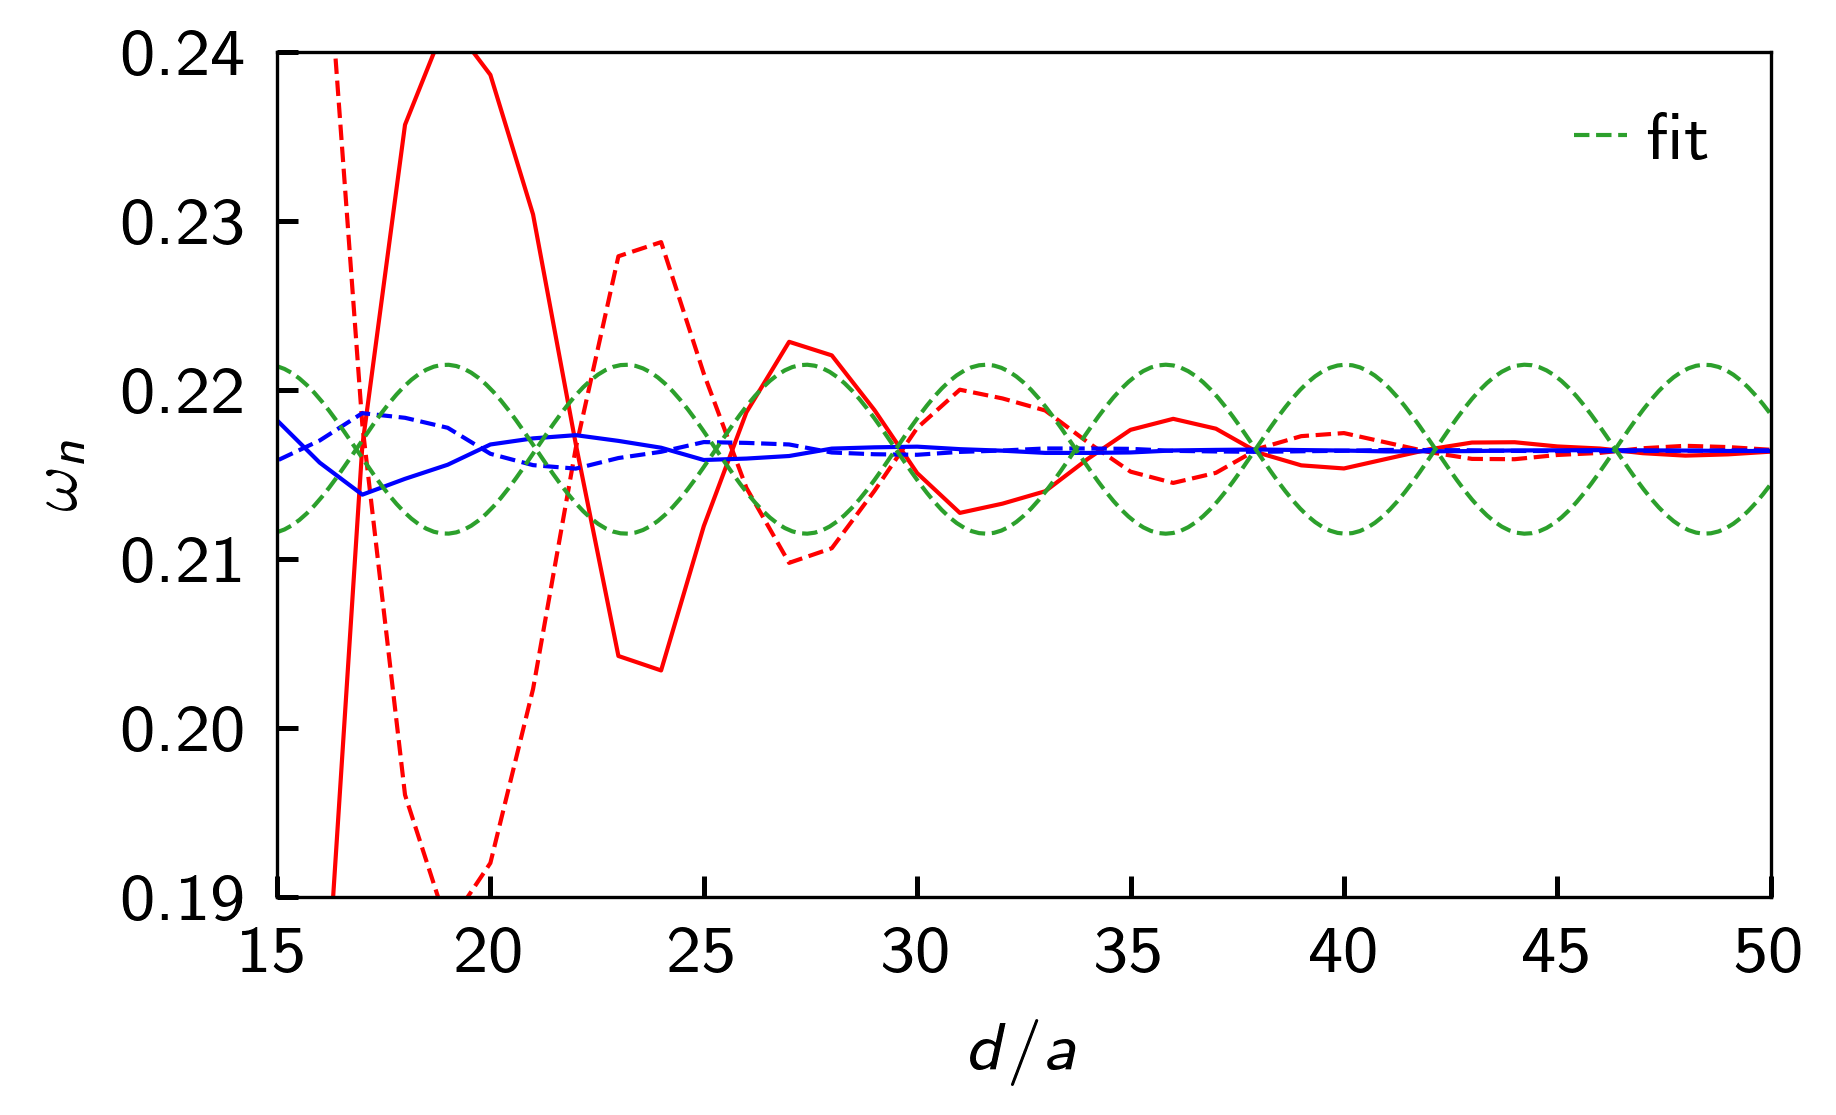

In [ ]:
fig, ax = plot_figure(29.50, 0.2165, (lmb_om+lmb_op)/2)

fig.savefig("imgs/fit.pdf")

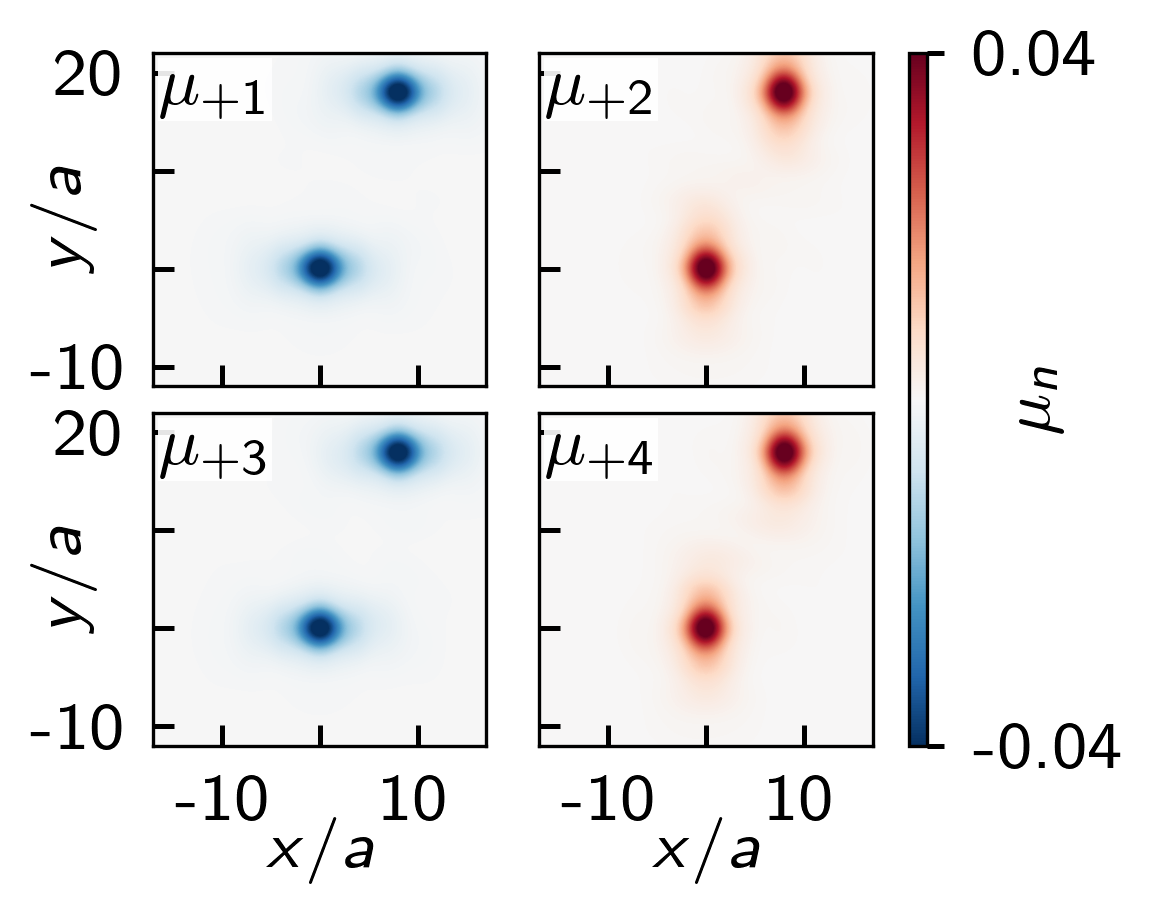

In [ ]:
d_1 = t0s0_op(vss[idxp, :, idxs[0]])
d_2 = t0s0_op(vss[idxp, :, idxs[1]])
d_3 = t0s0_op(vss[idxp, :, idxs[2]])
d_4 = t0s0_op(vss[idxp, :, idxs[3]])

m_1 = t0sz_op(vss[idxp, :, idxs[0]])
m_2 = t0sz_op(vss[idxp, :, idxs[1]])
m_3 = t0sz_op(vss[idxp, :, idxs[2]])
m_4 = t0sz_op(vss[idxp, :, idxs[3]])


# Create figure and gridspace for subplots
fig = plt.figure(figsize=(1.7, 1.5))
gs = fig.add_gridspec(
    2, 3, width_ratios=[1, 1, 0.05], height_ratios=[1, 1], wspace=0.08, hspace=0.08
)


# Create subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
cax = fig.add_subplot(gs[:, 2])

# # Determine color limits
# vmax = np.max(np.abs([d_1, d_2, d_3, d_4]))
# vmin = 0

# im1d = kwant.plotter.density(fsyst, d_1, ax=ax1, cmap="Grays", vmin=vmin, vmax=vmax)
# im2d = kwant.plotter.density(fsyst, d_2, ax=ax2, cmap="Grays", vmin=vmin, vmax=vmax)
# im3d = kwant.plotter.density(fsyst, d_3, ax=ax3, cmap="Grays", vmin=vmin, vmax=vmax)
# im4d = kwant.plotter.density(fsyst, d_4, ax=ax4, cmap="Grays", vmin=vmin, vmax=vmax)

# Determine color limits
vmax = np.max(np.abs([m_1, m_2, m_3, m_4]))
vmin = -vmax

# Plot densities with kwant.plotter.density
im1m = kwant.plotter.density(fsyst, m_1, ax=ax1, cmap="RdBu_r", vmin=vmin, vmax=vmax)
im2m = kwant.plotter.density(fsyst, m_2, ax=ax2, cmap="RdBu_r", vmin=vmin, vmax=vmax)
im3m = kwant.plotter.density(fsyst, m_3, ax=ax3, cmap="RdBu_r", vmin=vmin, vmax=vmax)
im4m = kwant.plotter.density(fsyst, m_4, ax=ax4, cmap="RdBu_r", vmin=vmin, vmax=vmax)


# for ax in [ax1, ax2, ax3, ax4]:
#     ax.images[0].set_alpha(0.5)
#     ax.images[1].set_alpha(0.5)

# Set lims
xlims = (-17, 17)
ylims = (-12, 22)
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)

# Remove axis labels for inner plots
ax1.set_yticks([-10, 0, 10, 20], labels=["-10", "", "", "20"])
ax3.set_yticks([-10, 0, 10, 20], labels=["-10", "", "", "20"])

for ax in [ax2, ax4]:
    ax.set_yticks([-10, 0, 10, 20], labels=[])

# Remove axis labels for inner plots
ax3.set_xticks([-10, 0, 10], labels=["-10", "", "10"])
ax4.set_xticks([-10, 0, 10], labels=["-10", "", "10"])

for ax in [ax1, ax2]:
    ax.set_xticks([-10, 0, 10], labels=[])  # labels=["-20", "", "20"])


ax1.set_ylabel(r"$y/a$", labelpad=-8)
ax3.set_ylabel(r"$y/a$", labelpad=-8)
ax3.set_xlabel(r"$x/a$", labelpad=-2)
ax4.set_xlabel(r"$x/a$", labelpad=-2)

# Adjust z-order and apply rasterization
for ax in [ax1, ax2, ax3, ax4]:
    ax.images[0].set_zorder(-1)
    ax.set_rasterization_zorder(0)

# Add titles for each subplot
add_tl_label(ax1, r"$\mu_{+1}$")
add_tl_label(ax2, r"$\mu_{+2}$")
add_tl_label(ax3, r"$\mu_{+3}$")
add_tl_label(ax4, r"$\mu_{+4}$")

# Create a common colorbar on the right
# fig.subplots_adjust(right=0.85, left=0.05, bottom=0.05, top=0.95)
cbar = fig.colorbar(ax1.images[0], cax=cax, cmap="RdBu_r")
cbar.set_ticks([vmin, vmax], labels=[f"{vmin:.2f}", f"{vmax:.2f}"])
cbar.ax.tick_params(axis="both", which="both", length=2, direction="out")
cbar.set_label(r"$\mu_n$", labelpad=-14)